In [1]:
import numpy
import sklearn
import sklearn.datasets
import sklearn.model_selection
import sklearn.decomposition
import sklearn.neighbors
import sklearn.metrics

In [2]:
digits = sklearn.datasets.load_digits()
X= digits.data
Y= digits.target
print(X.shape, Y.shape)


(1797, 64) (1797,)


## 1. Análisis del conjunto de datos

Mostrar un elemento

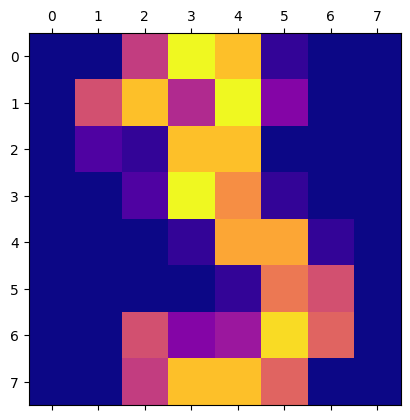

In [3]:
import matplotlib.pyplot as plt

plt.matshow(numpy.reshape(X[3],[8,8]),cmap='plasma')
plt.show()

Mostrar media

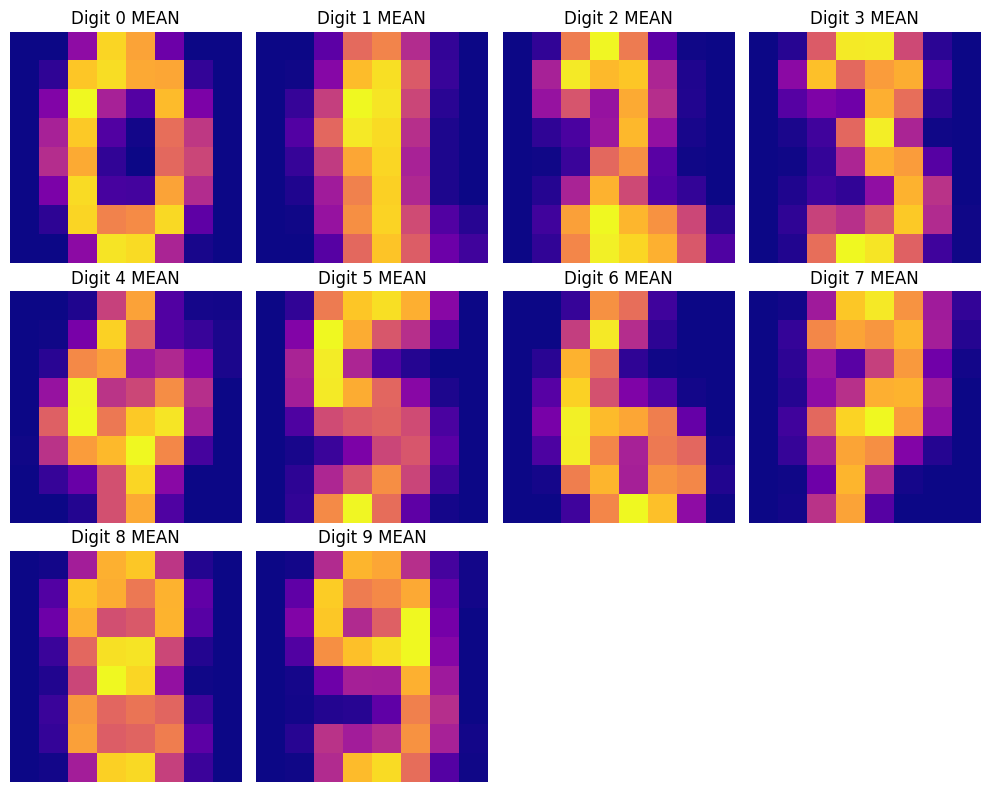

In [4]:

# Creamos array de imagenes(subplots)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

axes = axes.ravel()   # flatten to 1D for easy indexing

# Cargamos las imágenes de X
for digit in range(10):
    ax = axes[digit]
    ax.imshow(numpy.mean(X[Y == digit], axis=0).reshape(8, 8), cmap='plasma')
    ax.set_title(f"Digit {digit} MEAN")
    ax.axis('off')

# Hide remaining empty subplots (slots 10 and 11)
for i in range(10, 12):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Desviación típica

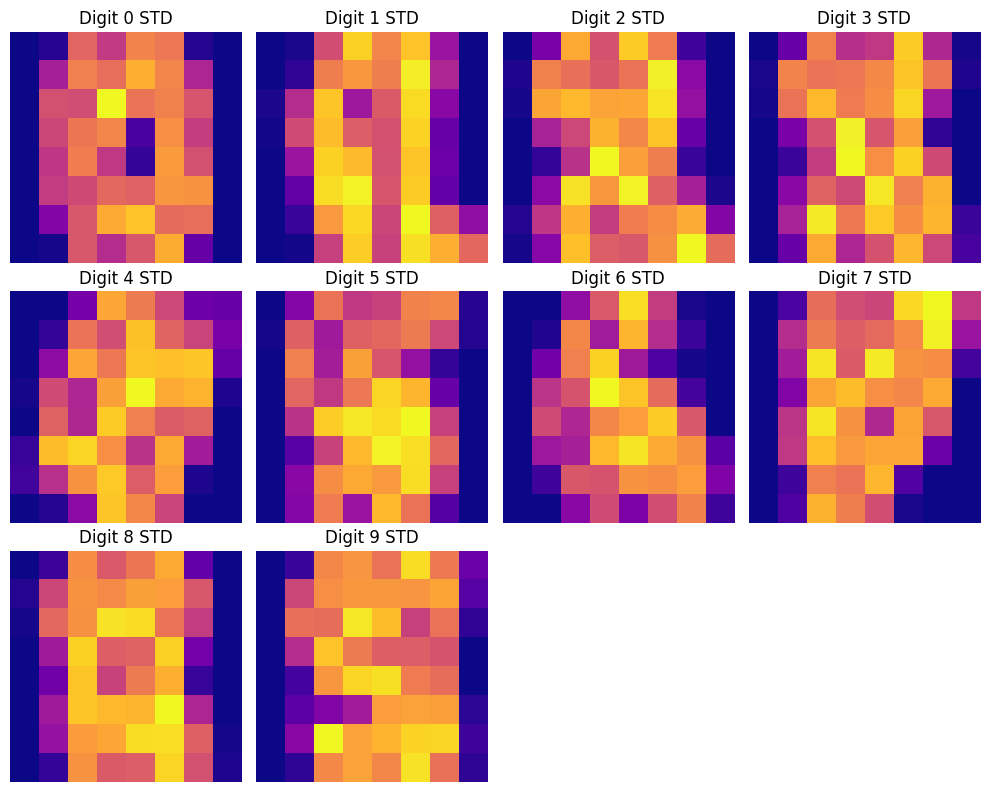

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

axes = axes.ravel()   # flatten to 1D for easy indexing

for digit in range(10):
    ax = axes[digit]
    ax.imshow(numpy.std(X[Y == digit], axis=0).reshape(8, 8), cmap='plasma')
    ax.set_title(f"Digit {digit} STD")
    ax.axis('off')

# Hide remaining empty subplots (slots 10 and 11)
for i in range(10, 12):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 2. División (train, test) y normalización

Dividimos muestras en conjuntos train y test

In [6]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, Y, test_size=0.30, random_state=42)

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1257, 64)
(540, 64)
(1257,)
(540,)


In [8]:
for digits in range(10):
    print("El nombre de imatges amb el digit {} és {}".format(digits,numpy.sum(Y==digits)))
for digits in range(10):
    print("El nombre de imatges de train amb el digit {} és {}".format(digits,numpy.sum(y_train==digits)))
for digits in range(10):
    print("El nombre de imatges de test amb el digit {} és {}".format(digits,numpy.sum(y_test==digits)))

El nombre de imatges amb el digit 0 és 178
El nombre de imatges amb el digit 1 és 182
El nombre de imatges amb el digit 2 és 177
El nombre de imatges amb el digit 3 és 183
El nombre de imatges amb el digit 4 és 181
El nombre de imatges amb el digit 5 és 182
El nombre de imatges amb el digit 6 és 181
El nombre de imatges amb el digit 7 és 179
El nombre de imatges amb el digit 8 és 174
El nombre de imatges amb el digit 9 és 180
El nombre de imatges de train amb el digit 0 és 125
El nombre de imatges de train amb el digit 1 és 132
El nombre de imatges de train amb el digit 2 és 130
El nombre de imatges de train amb el digit 3 és 129
El nombre de imatges de train amb el digit 4 és 121
El nombre de imatges de train amb el digit 5 és 116
El nombre de imatges de train amb el digit 6 és 128
El nombre de imatges de train amb el digit 7 és 124
El nombre de imatges de train amb el digit 8 és 131
El nombre de imatges de train amb el digit 9 és 121
El nombre de imatges de test amb el digit 0 és 53


Normalizamos los datos de forma manual

In [9]:
u_train=numpy.mean(X_train, axis=0)
sd_train=numpy.std(X_train,axis=0)


In [10]:
X_train_standard_scaled=(X_train-u_train)/sd_train

# Manejamos valores donde sd_train es 0
X_train_standard_scaled[numpy.where(numpy.isnan(X_train_standard_scaled))]=X_train[numpy.where(numpy.isnan(X_train_standard_scaled))]

print(numpy.mean(X_train_standard_scaled,axis=0))
print(numpy.std(X_train_standard_scaled,axis=0))

[ 0.00000000e+00  4.90370583e-16 -2.52604443e-17 -1.04249015e-16
 -1.07401050e-16  1.99610504e-17  3.16462140e-16 -2.06676363e-17
 -7.45227269e-18 -1.92544645e-17 -7.87843228e-17 -2.03143433e-18
  6.85388279e-17  9.07079591e-17 -1.51562666e-16 -2.09811837e-16
 -6.22568381e-17  3.02418746e-16  4.71646058e-17  5.29939391e-19
 -2.72035554e-17 -2.66736160e-17  1.41847110e-16 -7.28666663e-17
 -4.11928513e-16 -8.67334137e-17 -6.29068419e-17 -5.98831512e-17
  8.63801208e-17 -1.54212363e-16  2.38296080e-16 -5.05683624e-16
  0.00000000e+00 -6.27094946e-18  5.76750704e-17 -5.72334543e-17
  1.66930908e-17 -8.12573733e-17  6.25328482e-17  0.00000000e+00
 -2.88375352e-16  3.10721130e-16  1.02454949e-17 -2.40239191e-17
  1.30674222e-16  6.83621815e-17 -9.17678379e-17  4.91585028e-16
  1.29625383e-16  7.10118784e-17  8.08599188e-17  9.90986662e-17
 -3.64333331e-17 -1.44850100e-17  7.15418178e-17  1.45954141e-16
  2.90787680e-16  6.31422785e-16  5.03442422e-18 -6.52487875e-17
 -3.06106241e-16  2.02260

/tmp/ipython-input-2747501166.py:1: RuntimeWarning: invalid value encountered in divide
  X_train_standard_scaled=(X_train-u_train)/sd_train


Normalizamos los datos mediante librería de sklearn

In [11]:
import sklearn.preprocessing as preprocessing

scaler=preprocessing.StandardScaler()
X_train_standard_scaled_sklearn=scaler.fit_transform(X_train)
X_test_standard_scaled_sklearn=scaler.transform(X_test)

print(numpy.mean(X_train_standard_scaled_sklearn,axis=0))
print(numpy.std(X_train_standard_scaled_sklearn,axis=0))

[ 0.00000000e+00  4.90370583e-16 -2.52604443e-17 -1.04249015e-16
 -1.07401050e-16  1.99610504e-17  3.16462140e-16 -2.06676363e-17
 -7.45227269e-18 -1.92544645e-17 -7.87843228e-17 -2.03143433e-18
  6.85388279e-17  9.07079591e-17 -1.51562666e-16 -2.09811837e-16
 -6.22568381e-17  3.02418746e-16  4.71646058e-17  5.29939391e-19
 -2.72035554e-17 -2.66736160e-17  1.41847110e-16 -7.28666663e-17
 -4.11928513e-16 -8.67334137e-17 -6.29068419e-17 -5.98831512e-17
  8.63801208e-17 -1.54212363e-16  2.38296080e-16 -5.05683624e-16
  0.00000000e+00 -6.27094946e-18  5.76750704e-17 -5.72334543e-17
  1.66930908e-17 -8.12573733e-17  6.25328482e-17  0.00000000e+00
 -2.88375352e-16  3.10721130e-16  1.02454949e-17 -2.40239191e-17
  1.30674222e-16  6.83621815e-17 -9.17678379e-17  4.91585028e-16
  1.29625383e-16  7.10118784e-17  8.08599188e-17  9.90986662e-17
 -3.64333331e-17 -1.44850100e-17  7.15418178e-17  1.45954141e-16
  2.90787680e-16  6.31422785e-16  5.03442422e-18 -6.52487875e-17
 -3.06106241e-16  2.02260

## 3. Proyección de los componentes principales

Reducción de dimensionalidad

In [12]:
pca=sklearn.decomposition.PCA(n_components=3)
X_train_pca=pca.fit_transform(X_train)
print(X_train_pca)

svd=sklearn.decomposition.TruncatedSVD(n_components=3)
X_train_svd=svd.fit_transform(X_train)
print(X_train_svd)

# KernelPCA
kpca = sklearn.decomposition.KernelPCA(n_components=3, kernel='linear', gamma=None)
X_train_kpca = kpca.fit_transform(X_train)
print(X_train_kpca)
print(X_train_kpca.shape)

pca=sklearn.decomposition.PCA(n_components=3)
X_train_pca_ss=pca.fit_transform(X_train_standard_scaled_sklearn)
print(X_train_pca_ss)

svd=sklearn.decomposition.TruncatedSVD(n_components=3)
X_train_svd_ss=svd.fit_transform(X_train_standard_scaled_sklearn)
print(X_train_svd_ss)

# KernelPCA con data normalizada
kpca_ss = sklearn.decomposition.KernelPCA(n_components=3, kernel='linear', gamma=None)
X_train_kpca_ss = kpca_ss.fit_transform(X_train_standard_scaled_sklearn)
print(X_train_kpca_ss)


[[ -5.23975138  -9.95876489   3.96539622]
 [ -1.38392091  17.35920436  17.65473249]
 [  9.26126771   8.52459835 -22.72039396]
 ...
 [-13.09234588  10.60533352   1.62512208]
 [  3.59709683   7.88611228  16.52985818]
 [ 13.94061191  18.07369859 -11.11133161]]
[[ 66.72181589  -5.34702989 -10.45373133]
 [ 55.98187112  -1.43521276  17.33356555]
 [ 48.60589358   9.22331889   8.36471557]
 ...
 [ 58.19915806 -13.1677186   10.35938861]
 [ 53.99146455   3.57163917   7.90844574]
 [ 47.6480294   13.90273685  18.02293979]]
[[ -5.23975138   9.95876489  -3.96539622]
 [ -1.38392091 -17.35920436 -17.65473249]
 [  9.26126771  -8.52459835  22.72039396]
 ...
 [-13.09234588 -10.60533352  -1.62512208]
 [  3.59709683  -7.88611228 -16.52985818]
 [ 13.94061191 -18.07369859  11.11133161]]
(1257, 3)
[[-0.158822    0.13008809 -2.05083954]
 [-1.06496645  3.54094052  1.11566692]
 [ 1.60053217 -4.15197884  4.84268069]
 ...
 [ 1.63729675  2.26052812  0.54275447]
 [-1.68589846  1.80446546  0.28150265]
 [-0.32684191 -0

In [13]:
import sklearn.discriminant_analysis

lda=sklearn.discriminant_analysis.LinearDiscriminantAnalysis(n_components=9) # N -1
X_train_lda=lda.fit_transform(X_train,y_train)
print(X_train_lda)

lda_ss=sklearn.discriminant_analysis.LinearDiscriminantAnalysis(n_components=9)
X_train_lda_ss=lda_ss.fit_transform(X_train_standard_scaled_sklearn,y_train)
print(X_train_lda_ss)



[[ 1.95264672 -0.26434448  0.17623824 ... -1.60456401  2.66951494
   1.27168677]
 [-0.29612961  0.56653394 -5.30459968 ... -0.58933995 -1.04211398
  -0.10345925]
 [ 1.74111509  3.27151435  2.2492438  ... -1.5202473  -2.61745465
  -2.14446346]
 ...
 [ 4.54496771  2.3938882   1.11503044 ... -0.72859464 -0.9246636
  -0.04003681]
 [-1.87123486  0.84752736 -2.91570257 ... -0.65865692 -0.70665312
  -0.11317862]
 [-0.92239771  1.87811969  1.06930442 ... -1.35603009 -1.96934567
  -0.47925166]]
[[ 1.95264672 -0.26434448  0.17623824 ... -1.60456401  2.66951494
   1.27168677]
 [-0.29612961  0.56653394 -5.30459968 ... -0.58933995 -1.04211398
  -0.10345925]
 [ 1.74111509  3.27151435  2.2492438  ... -1.5202473  -2.61745465
  -2.14446346]
 ...
 [ 4.54496771  2.3938882   1.11503044 ... -0.72859464 -0.9246636
  -0.04003681]
 [-1.87123486  0.84752736 -2.91570257 ... -0.65865692 -0.70665312
  -0.11317862]
 [-0.92239771  1.87811969  1.06930442 ... -1.35603009 -1.96934567
  -0.47925166]]


Muestreo

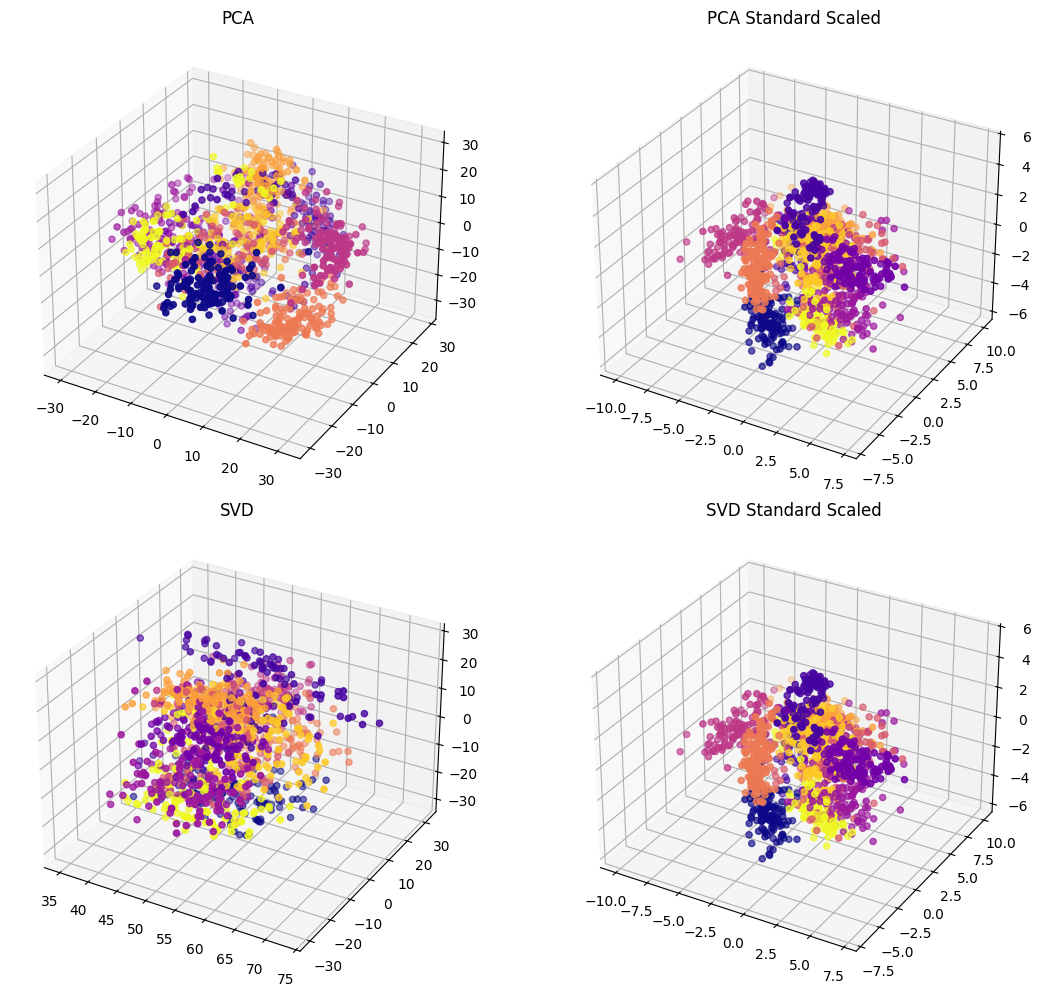

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={"projection": "3d"})


axes[0,0].scatter(X_train_pca[:,0],X_train_pca[:,1],X_train_pca[:,2],c=y_train,cmap='plasma')
axes[0,0].set_title('PCA')

axes[0,1].scatter(X_train_pca_ss[:,0],X_train_pca_ss[:,1],X_train_pca_ss[:,2],c=y_train,cmap='plasma')
axes[0,1].set_title('PCA Standard Scaled')

axes[1,0].scatter(X_train_svd[:,0],X_train_svd[:,1],X_train_svd[:,2],c=y_train,cmap='plasma')
axes[1,0].set_title('SVD')

axes[1,1].scatter(X_train_svd_ss[:,0],X_train_svd_ss[:,1],X_train_svd_ss[:,2],c=y_train,cmap='plasma')
axes[1,1].set_title('SVD Standard Scaled')

plt.tight_layout()
plt.show()

Text(0.5, 0.92, 'LDA Standard Scaled')

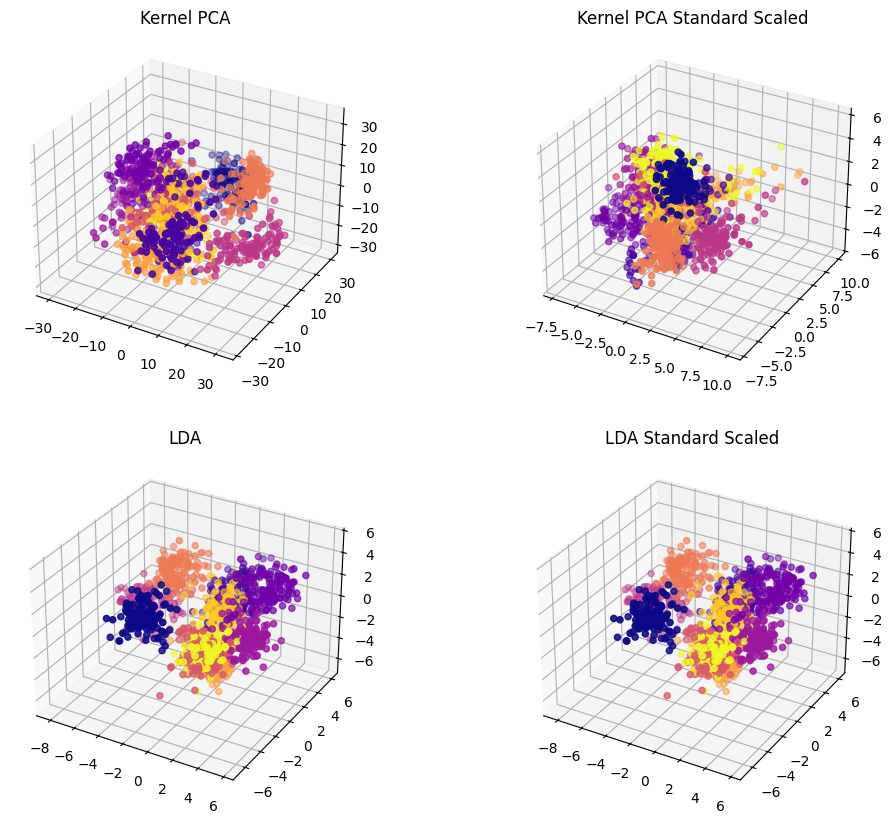

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={"projection": "3d"})

axes[0,0].scatter(X_train_kpca[:,0],X_train_kpca[:,1],X_train_kpca[:,2],c=y_train,cmap='plasma')
axes[0,0].set_title('Kernel PCA')

axes[0,1].scatter(X_train_kpca_ss[:,0],X_train_kpca_ss[:,1],X_train_kpca_ss[:,2],c=y_train,cmap='plasma')
axes[0,1].set_title('Kernel PCA Standard Scaled')

axes[1,0].scatter(X_train_lda[:,0],X_train_lda[:,1],X_train_lda[:,2],c=y_train,cmap='plasma')
axes[1,0].set_title('LDA')

axes[1,1].scatter(X_train_lda_ss[:,0],X_train_lda_ss[:,1],X_train_lda_ss[:,2],c=y_train,cmap='plasma')
axes[1,1].set_title('LDA Standard Scaled')



## 4. Predicción

In [16]:
n_neighbors=5

# PCA
clf_pca=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_pca.fit(X_train_pca,y_train)

y_predicted = clf_pca.predict(pca.fit_transform(X_test))

print("PCA")
print(sklearn.metrics.classification_report(y_test,y_predicted))

clf_pca_ss=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_pca_ss.fit(X_train_pca_ss,y_train)

y_predicted = clf_pca_ss.predict(pca.fit_transform(X_test_standard_scaled_sklearn))

print("PCA_SS")
print(sklearn.metrics.classification_report(y_test,y_predicted))

# SVD
clf_svd=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_svd.fit(X_train_svd,y_train)

y_predicted = clf_svd.predict(svd.fit_transform(X_test))

print("SVD")
print(sklearn.metrics.classification_report(y_test,y_predicted))

clf_svd_ss=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_svd_ss.fit(X_train_svd_ss,y_train)

y_predicted = clf_svd_ss.predict(svd.fit_transform(X_test_standard_scaled_sklearn))

print("SVD_SS")
print(sklearn.metrics.classification_report(y_test,y_predicted))

# KPCA
clf_kpca=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_kpca.fit(X_train_kpca,y_train)

y_predicted = clf_kpca.predict(kpca.fit_transform(X_test))

print("KPCA")
print(sklearn.metrics.classification_report(y_test,y_predicted))

clf_kpca_ss=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_kpca_ss.fit(X_train_kpca_ss,y_train)

y_predicted = clf_kpca_ss.predict(kpca.fit_transform(X_test_standard_scaled_sklearn))

print("KPCA_SS")
print(sklearn.metrics.classification_report(y_test,y_predicted))

# LDA
clf_lda=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_lda.fit(X_train_lda,y_train)

y_predicted = clf_lda.predict(lda.transform(X_test))

print("LDA")
print(sklearn.metrics.classification_report(y_test,y_predicted))

clf_lda_ss=sklearn.neighbors.KNeighborsClassifier(n_neighbors,weights='distance')
clf_lda_ss.fit(X_train_lda_ss,y_train)

y_predicted = clf_lda_ss.predict(lda_ss.transform(X_test_standard_scaled_sklearn))

print("LDA_SS")
print(sklearn.metrics.classification_report(y_test,y_predicted))

PCA
              precision    recall  f1-score   support

           0       0.72      0.77      0.75        53
           1       0.43      0.58      0.49        50
           2       0.60      0.85      0.70        47
           3       0.55      0.69      0.61        54
           4       0.83      0.90      0.86        60
           5       0.36      0.23      0.28        66
           6       0.86      0.72      0.78        53
           7       0.60      0.38      0.47        55
           8       0.32      0.47      0.38        43
           9       0.44      0.24      0.31        59

    accuracy                           0.57       540
   macro avg       0.57      0.58      0.56       540
weighted avg       0.57      0.57      0.56       540

PCA_SS
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        53
           1       0.37      0.58      0.45        50
           2       0.02      0.02      0.02        47
           3 

## 5. Análisis de resultados

In [17]:
def compute_test(X,y,clf,cv=10):
    KFolds=sklearn.model_selection.KFold(n_splits=10)
    scores=[]
    for train,test in KFolds.split(X):
        clf.fit(X[train],y[train])
        pred_values=clf.predict(X[test])
        scores.append(sklearn.metrics.accuracy_score(pred_values,y[test]))
    return scores

In [18]:
from sklearn.pipeline import Pipeline

# Pipeline: note the (name, step) tuples
clf = Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("lda", sklearn.discriminant_analysis.LinearDiscriminantAnalysis(n_components=9)),
    ("knn", sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, weights='distance')),
])

scores=compute_test(X,Y,clf,10)
print("Final accuracy is {:.2f}%".format(numpy.mean(scores)*100))


Final accuracy is 94.66%


## 6. Búsqueda de algoritmo y valores óptimos



In [19]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


In [20]:
pipelines = []
param_grids = []
results = {}

# KNeighborsClassifier
knn = sklearn.neighbors.KNeighborsClassifier(weights='distance')

# n_neighbors range
knn_n_neighbors_range = list(range(1, 13)) # 1 to 12

# n_components range for PCA, SVD, KernelPCA
dr_n_components_large_range = list(range(5, 51, 5)) # 5 to 50, cada 5

# n_components range for LDA (N -1)
dr_n_components_lda_range = list(range(2, 10)) # 2 to 9


# 1. PCA without StandardScaler
pipeline_pca = Pipeline([
    ('pca', sklearn.decomposition.PCA()),
    ('kneighborsclassifier', knn)
])
param_grid_pca = {
    'pca__n_components': dr_n_components_large_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('PCA', pipeline_pca, param_grid_pca))

# 2. PCA with StandardScaler
pipeline_pca_ss = Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('pca', sklearn.decomposition.PCA()),
    ('kneighborsclassifier', knn)
])
param_grid_pca_ss = {
    'pca__n_components': dr_n_components_large_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('PCA_SS', pipeline_pca_ss, param_grid_pca_ss))

# 3. TruncatedSVD without StandardScaler
pipeline_svd = Pipeline([
    ('truncatedsvd', sklearn.decomposition.TruncatedSVD()),
    ('kneighborsclassifier', knn)
])
param_grid_svd = {
    'truncatedsvd__n_components': dr_n_components_large_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('SVD', pipeline_svd, param_grid_svd))

# 4. TruncatedSVD with StandardScaler
pipeline_svd_ss = Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('truncatedsvd', sklearn.decomposition.TruncatedSVD()),
    ('kneighborsclassifier', knn)
])
param_grid_svd_ss = {
    'truncatedsvd__n_components': dr_n_components_large_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('SVD_SS', pipeline_svd_ss, param_grid_svd_ss))

# 5. KernelPCA without StandardScaler
pipeline_kpca = Pipeline([
    ('kernelpca', sklearn.decomposition.KernelPCA(kernel='linear')),
    ('kneighborsclassifier', knn)
])
param_grid_kpca = {
    'kernelpca__n_components': dr_n_components_large_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('KPCA', pipeline_kpca, param_grid_kpca))

# 6. KernelPCA with StandardScaler
pipeline_kpca_ss = Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('kernelpca', sklearn.decomposition.KernelPCA(kernel='linear')),
    ('kneighborsclassifier', knn)
])
param_grid_kpca_ss = {
    'kernelpca__n_components': dr_n_components_large_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('KPCA_SS', pipeline_kpca_ss, param_grid_kpca_ss))

# 7. LDA without StandardScaler
pipeline_lda = Pipeline([
    ('lineardiscriminantanalysis', sklearn.discriminant_analysis.LinearDiscriminantAnalysis()),
    ('kneighborsclassifier', knn)
])
param_grid_lda = {
    'lineardiscriminantanalysis__n_components': dr_n_components_lda_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('LDA', pipeline_lda, param_grid_lda))

# 8. LDA with StandardScaler
pipeline_lda_ss = Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('lineardiscriminantanalysis', sklearn.discriminant_analysis.LinearDiscriminantAnalysis()),
    ('kneighborsclassifier', knn)
])
param_grid_lda_ss = {
    'lineardiscriminantanalysis__n_components': dr_n_components_lda_range,
    'kneighborsclassifier__n_neighbors': knn_n_neighbors_range
}
pipelines.append(('LDA_SS', pipeline_lda_ss, param_grid_lda_ss))



In [21]:
for name, pipeline, param_grid in pipelines:
    print(f"Performing GridSearchCV for {name}...")
    grid_search = GridSearchCV(pipeline, param_grid, cv=10, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    results[name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'cv_results': grid_search.cv_results_
    }
    print(f"Finished {name}. Best Score: {grid_search.best_score_:.4f}, Best Params: {grid_search.best_params_}")

print("\n--- All GridSearchCV Results ---")
for name, res in results.items():
    print(f"\n{name}:")
    print(f"  Best Score: {res['best_score']:.4f}")
    print(f"  Best Params: {res['best_params']}")

Performing GridSearchCV for PCA...
Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Finished PCA. Best Score: 0.9889, Best Params: {'kneighborsclassifier__n_neighbors': 1, 'pca__n_components': 35}
Performing GridSearchCV for PCA_SS...
Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Finished PCA_SS. Best Score: 0.9769, Best Params: {'kneighborsclassifier__n_neighbors': 4, 'pca__n_components': 25}
Performing GridSearchCV for SVD...
Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Finished SVD. Best Score: 0.9889, Best Params: {'kneighborsclassifier__n_neighbors': 1, 'truncatedsvd__n_components': 35}
Performing GridSearchCV for SVD_SS...
Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Finished SVD_SS. Best Score: 0.9769, Best Params: {'kneighborsclassifier__n_neighbors': 4, 'truncatedsvd__n_components': 25}
Performing GridSearchCV for KPCA...
Fitting 10 folds for each of 120 candidates, totalling 1200 fits
Finished KPCA. Be

## 7. Visualizar la evolución de la búsqueda



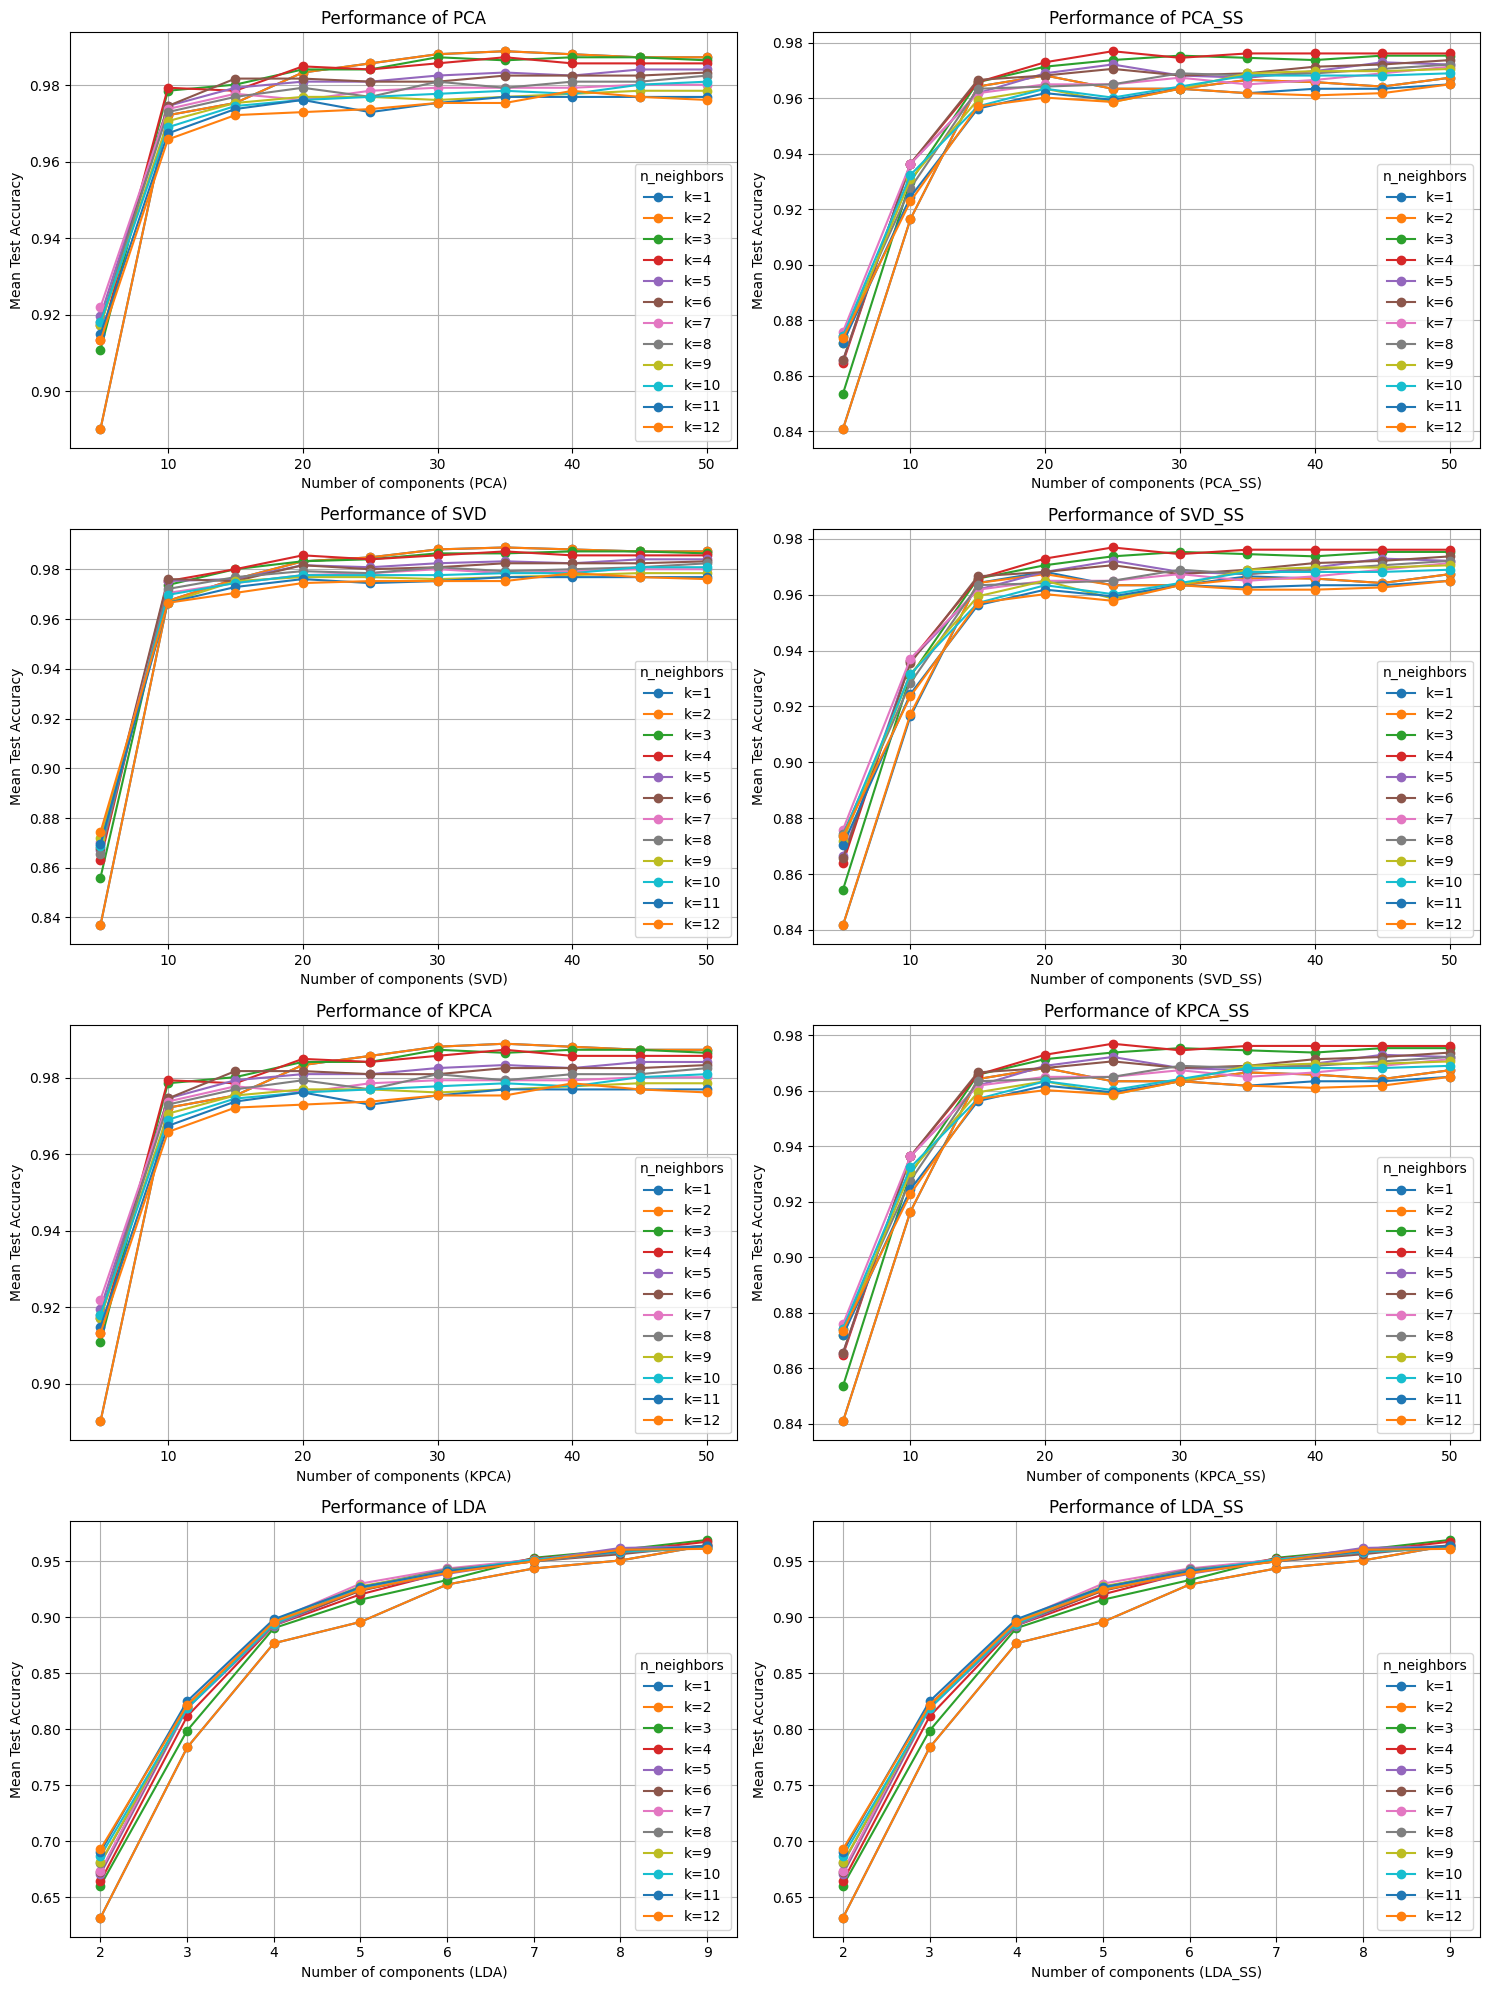

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Definir cuadricula gráficos
num_pipelines = len(results)

num_cols = 2
num_rows = num_pipelines // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    cv_results_df = pd.DataFrame(res['cv_results'])

    # Obtener el grid del pipeline actual
    current_param_grid = None
    for p_name, _, p_grid in pipelines:
        if p_name == name:
            current_param_grid = p_grid
            break

    # Obtener el nombre de la clave del parámetro n_components (ya que varía dependiendo del algoritmo)
    dr_param_original_key = None
    if current_param_grid:
        for key in current_param_grid.keys():
            if 'n_components' in key: # Si contiene "n_components"
                dr_param_original_key = key
                break

    if dr_param_original_key:
        dr_param_cv_results_key = 'param_' + dr_param_original_key

        # Comprobar que la key exista en el cv_results_df
        if dr_param_cv_results_key not in cv_results_df.columns:
            ax.set_title(f'Error plotting {name}: Missing column {dr_param_cv_results_key}')
            ax.text(0.5, 0.5, f"Column '{dr_param_cv_results_key}' not found", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            continue

        # Obtenemos los resultados obtenidos en orden de los neighbors de forma ascendente
        unique_n_neighbors = cv_results_df['param_kneighborsclassifier__n_neighbors'].unique()

        # Para cada grupo de resultados en base a los neighbors graficamos sus resultados por númmeor de componentes utilizados
        for n_neigh in sorted(unique_n_neighbors):
            subset = cv_results_df[cv_results_df['param_kneighborsclassifier__n_neighbors'] == n_neigh]
            # Comprobamos que el gráfico no esté vacio antes de graficar
            if not subset.empty:
                ax.plot(subset[dr_param_cv_results_key], subset['mean_test_score'], label=f'k={n_neigh}', marker='o')

        ax.set_title(f'Performance of {name}')
        ax.set_xlabel(f'Number of components ({name})')
        ax.set_ylabel('Mean Test Accuracy')
        ax.legend(title='n_neighbors')
        ax.grid(True)
    else:
        ax.set_title(f'Error plotting {name}: Could not find n_components parameter')

plt.tight_layout()
plt.show()